<a href="https://colab.research.google.com/github/Pranayshukla0610/Data-Science-Projects/blob/main/CNN_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

In [2]:
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
print("n\Training Images Shape:",X_train.shape)
print("Training Labels Shape:",y_train.shape)
print("Testing Images Shape:",X_test.shape)
print("Testing Labels Shape:",y_test.shape)

n\Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_5384/1742068443.py:1: SyntaxWarning: invalid escape sequence '\T'
  print("n\Training Images Shape:",X_train.shape)


In [5]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

In [6]:
for i, name in enumerate(class_names):
  print(i, ":", name)

0 : Airplane
1 : Automobile
2 : Bird
3 : Cat
4 : Deer
5 : Dog
6 : Frog
7 : Horse
8 : Ship
9 : Truck


In [7]:
print("n\Total Training Images:",len(X_train))
print("n\Total Testing Images:",len(X_test))

n\Total Training Images: 50000
n\Total Testing Images: 10000


<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:2: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:2: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_5384/2336851887.py:1: SyntaxWarning: invalid escape sequence '\T'
  print("n\Total Training Images:",len(X_train))
/tmp/ipykernel_5384/2336851887.py:2: SyntaxWarning: invalid escape sequence '\T'
  print("n\Total Testing Images:",len(X_test))


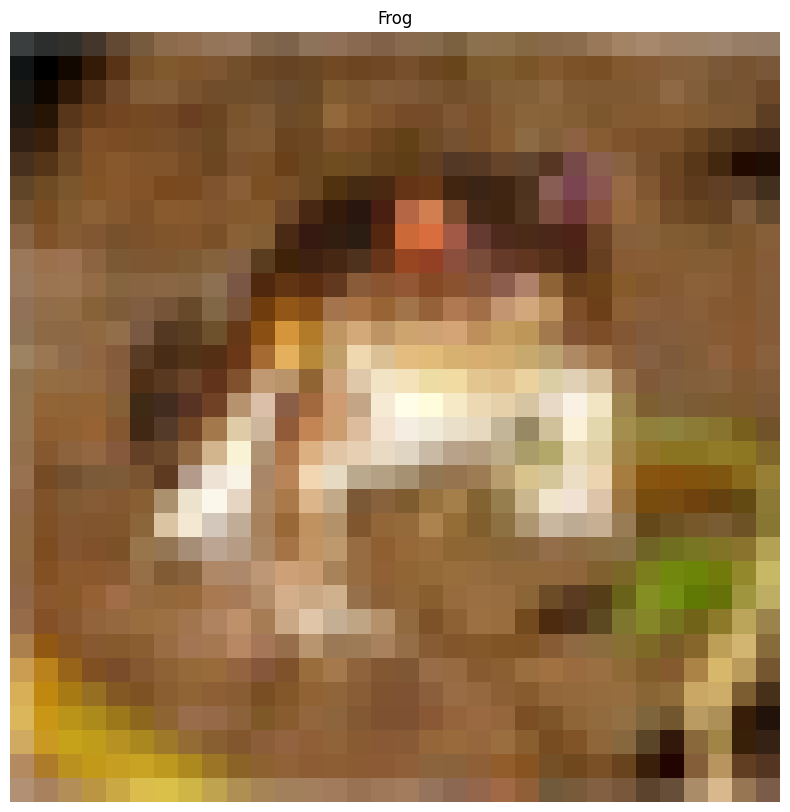

In [8]:
plt.figure(figsize=(16,10))
plt.imshow(X_train[0])
plt.title(class_names[y_train[0][0]])
plt.axis('off')
plt.show()

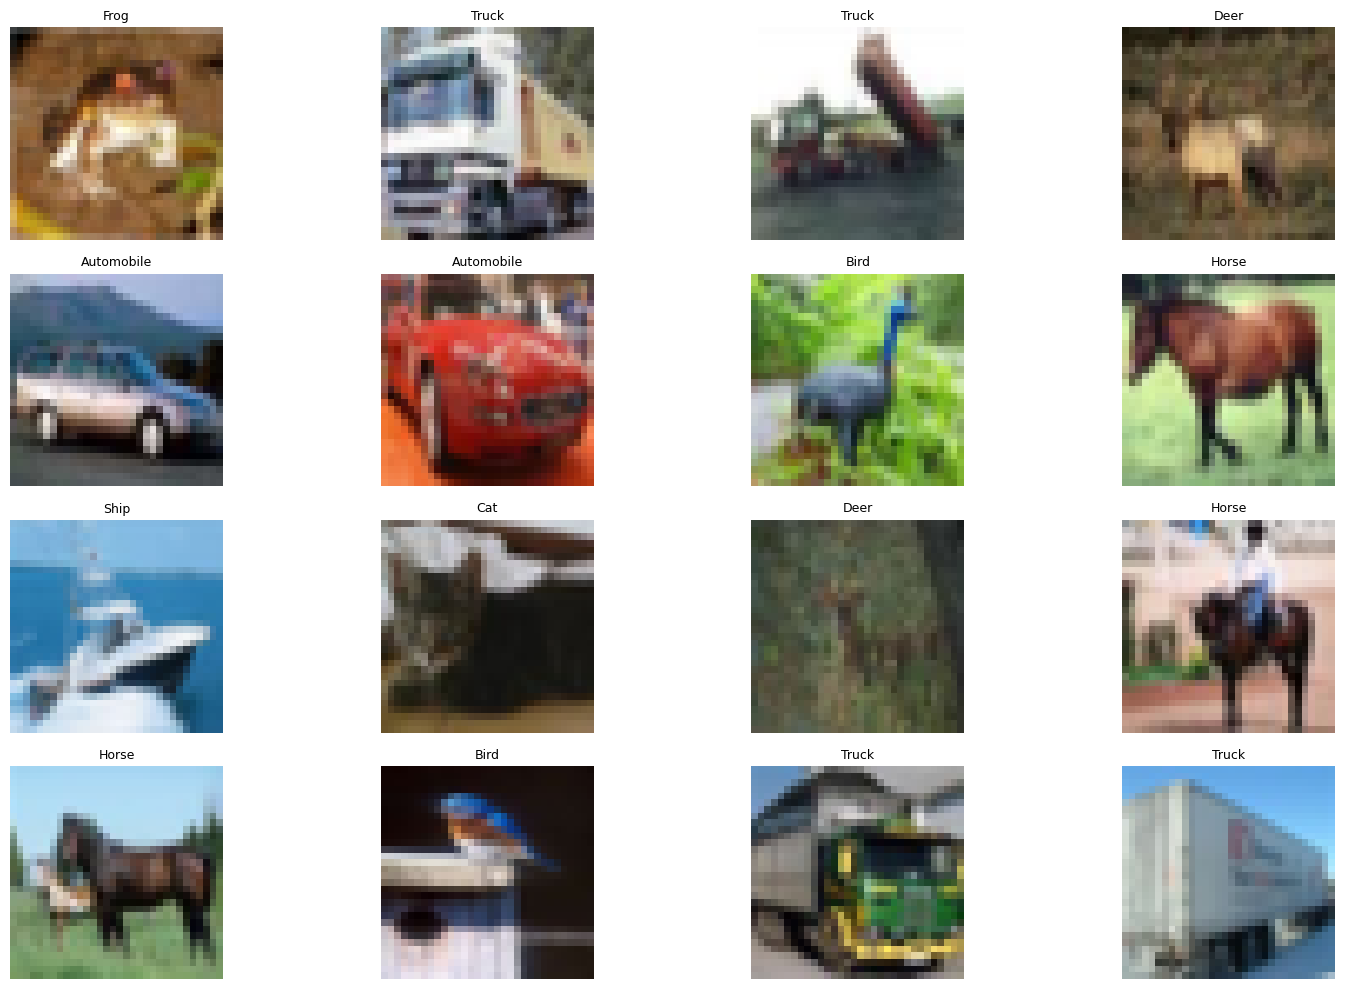

In [9]:
plt.figure(figsize=(16,10))
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.imshow(X_train[i])
  plt.title(class_names[y_train[i][0]],fontsize=9)
  plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
print("\nHeight :", X_train.shape[1])
print("Width  :", X_train.shape[2])
print("Channels :", X_train.shape[3])

print("\nEach image size = 32 x 32 x 3")


Height : 32
Width  : 32
Channels : 3

Each image size = 32 x 32 x 3


In [11]:
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [12]:
print("Missing Values in X_train:",np.isnan(X_train).sum())
print("Missing Values in X_test:",np.isnan(X_test).sum())

Missing Values in X_train: 0
Missing Values in X_test: 0


In [13]:
print("Missing Values in X_train:",np.isnan(y_train).sum())
print("Missing Values in X_test:",np.isnan(y_test).sum())

Missing Values in X_train: 0
Missing Values in X_test: 0


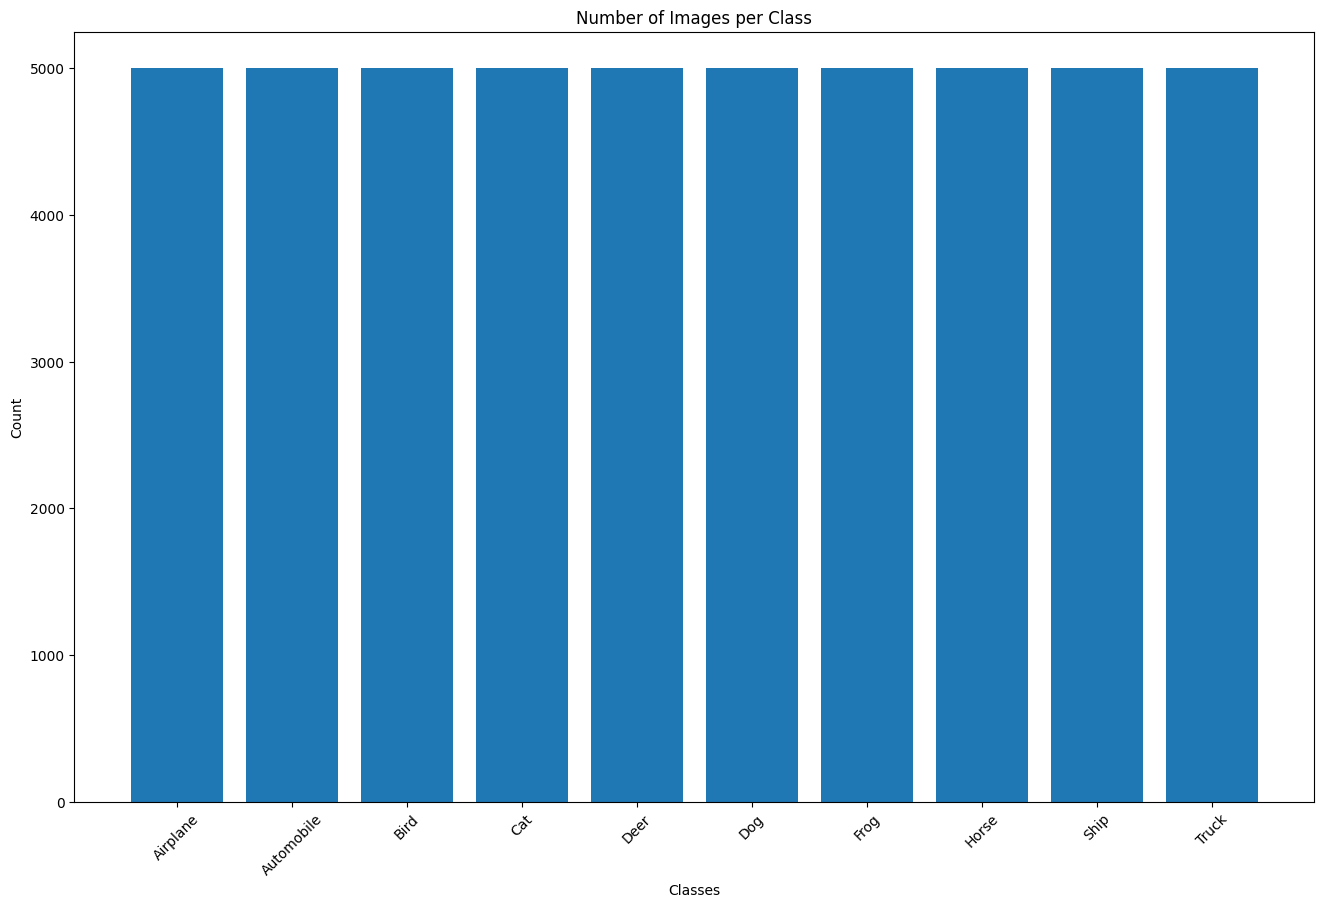

In [14]:
class_count = []
for i in range(len(class_names)):
  class_count.append(np.sum(y_train == i))

plt.figure(figsize=(16,10))
plt.bar(class_names,class_count)
plt.xticks(rotation=45)
plt.title("Number of Images per Class")
plt.xlabel('Classes')
plt.ylabel('Count')
plt.show()

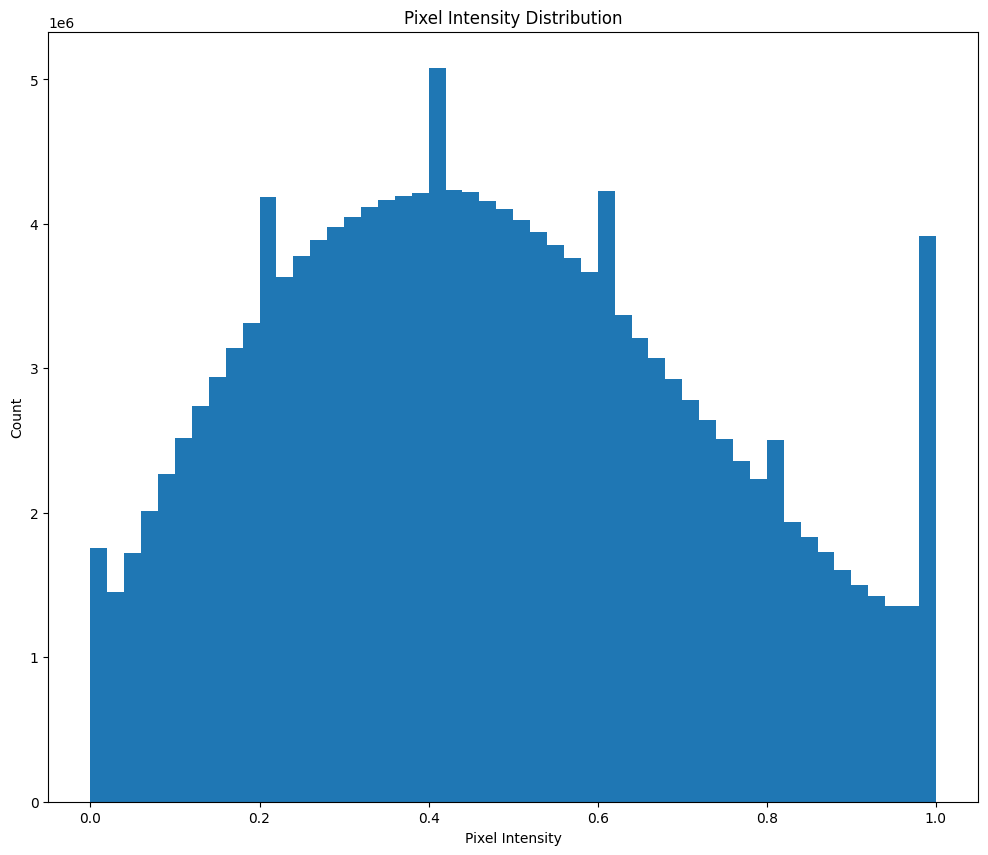

In [16]:
plt.figure(figsize=(12,10))
plt.hist(X_train.flatten(),bins=50)
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Intensity')
plt.ylabel('Count')
plt.show()

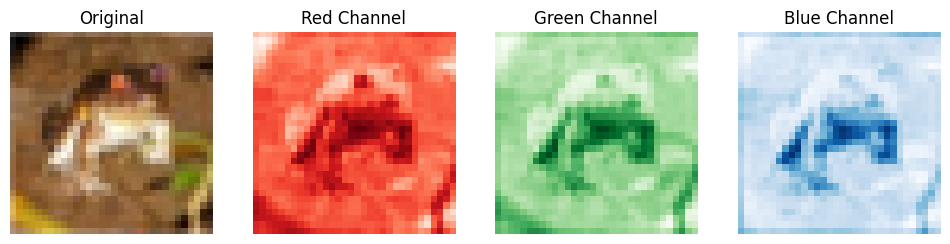

In [18]:
sample = X_train[0]

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(sample)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(sample[:,:,0], cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(sample[:,:,1], cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(sample[:,:,2], cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()


In [19]:
import cv2

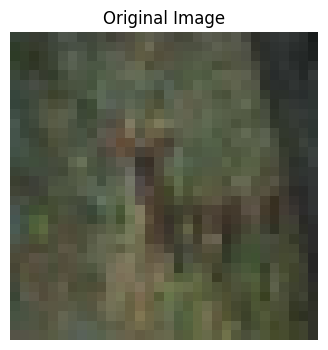

In [21]:
sample = X_train[10]
plt.figure(figsize=(4,4))
plt.imshow(sample)
plt.title('Original Image')
plt.axis('off')
plt.show()

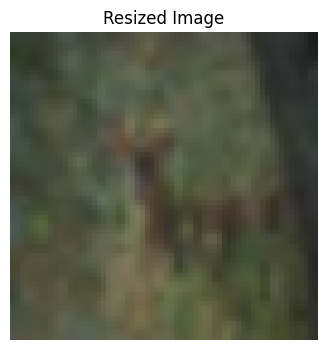

In [22]:
resized = cv2.resize(sample,(64,64))
plt.figure(figsize=(4,4))
plt.imshow(resized)
plt.title('Resized Image')
plt.axis('off')
plt.show()

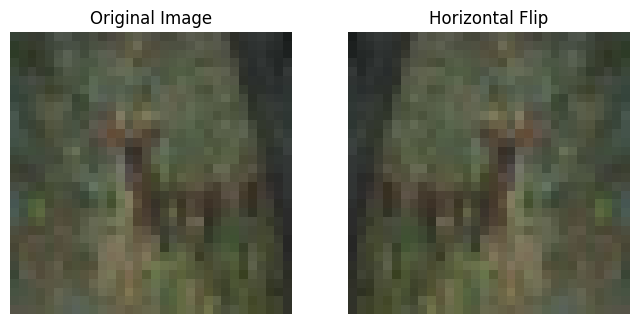

In [23]:
horizontal_flip = cv2.flip(sample,1)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(sample)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(horizontal_flip)
plt.title('Horizontal Flip')
plt.axis('off')
plt.show()

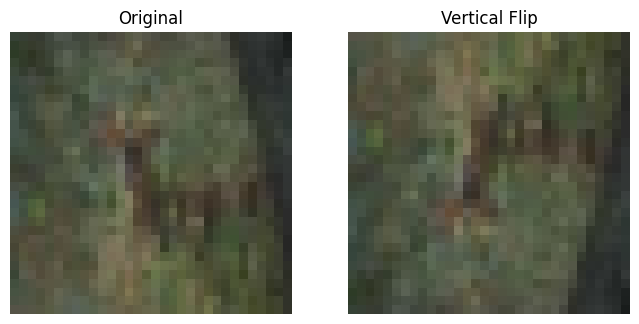

In [24]:
vertical_flip = cv2.flip(sample,0)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(vertical_flip)
plt.title("Vertical Flip")
plt.axis("off")

plt.show()

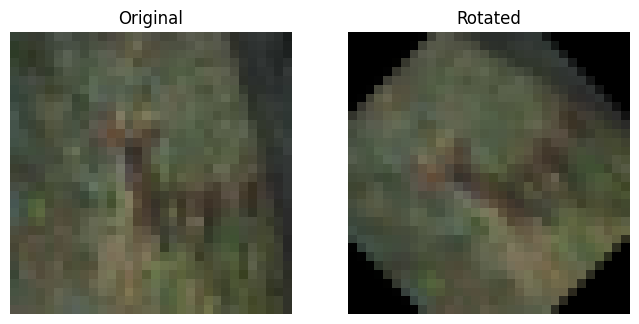

In [25]:
#Rotate Image
(h,w) = sample.shape[:2]
center = (w//2,h//2)
rotation_matrix = cv2.getRotationMatrix2D(center,45,1.0)

rotated = cv2.warpAffine(
    sample,
    rotation_matrix,
    (w,h)
)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(sample)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rotated)
plt.title("Rotated")
plt.axis("off")

plt.show()

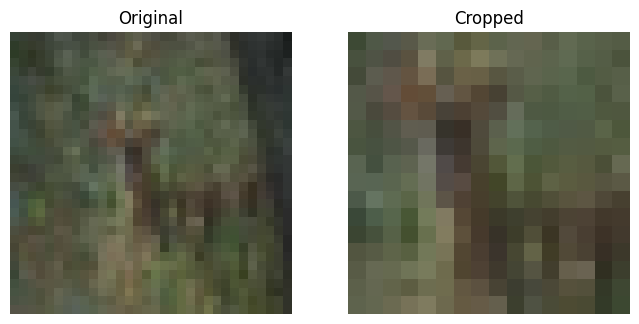

Cropped Shape : (16, 16, 3)


In [26]:
#Crop Imgae
cropped = sample[8:24,8:24]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cropped)
plt.title("Cropped")
plt.axis("off")

plt.show()

print("Cropped Shape :",cropped.shape)

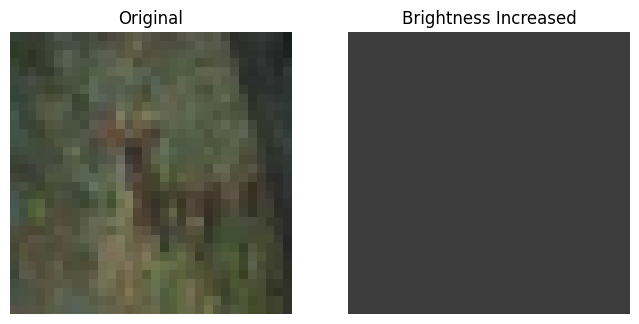

In [27]:
#Brightness Adjusted
bright = cv2.convertScaleAbs(sample,
                             alpha=1,
                             beta=60)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(bright)
plt.title("Brightness Increased")
plt.axis("off")

plt.show()

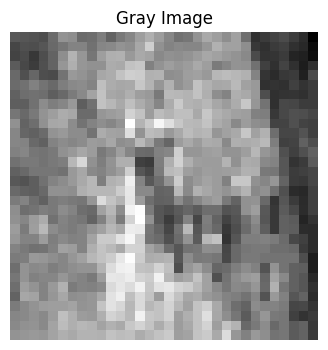

In [28]:
gray = cv2.cvtColor((sample*255).astype(np.uint8),cv2.COLOR_RGB2GRAY)
plt.figure(figsize=(4,4))
plt.imshow(gray,cmap='gray')
plt.title('Gray Image')
plt.axis('off')
plt.show()

In [29]:
print("Height :",gray.shape[0])

print("Width :",gray.shape[1])

print("Datatype :",gray.dtype)

print("Maximum :",gray.max())

print("Minimum :",gray.min())

Height : 32
Width : 32
Datatype : uint8
Maximum : 122
Minimum : 27


In [31]:
vertical_kernel = np.array([
    [1,0,-1],
    [1,0,-1],
    [1,0,-1]
])
print("\nVertical Kernel\n")

print(vertical_kernel)


Vertical Kernel

[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]


In [32]:
horizontal_kernel=np.array([
    [1,1,1],
    [0,0,0],
    [-1,-1,-1]
])

print("\nHorizontal Kernel\n")

print(horizontal_kernel)


Horizontal Kernel

[[ 1  1  1]
 [ 0  0  0]
 [-1 -1 -1]]


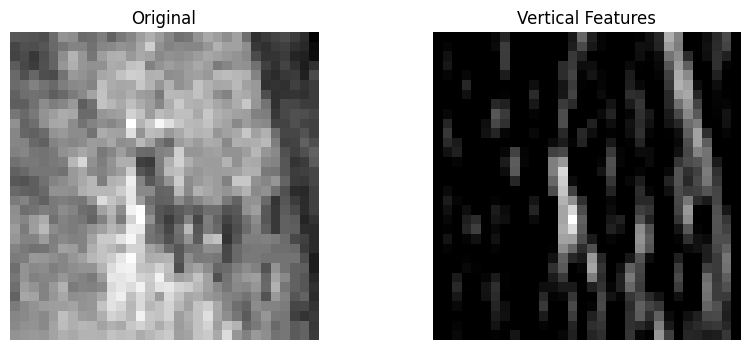

In [33]:
vertical=cv2.filter2D(gray,-1,vertical_kernel)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.imshow(gray,cmap="gray")

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(vertical,cmap="gray")

plt.title("Vertical Features")

plt.axis("off")

plt.show()

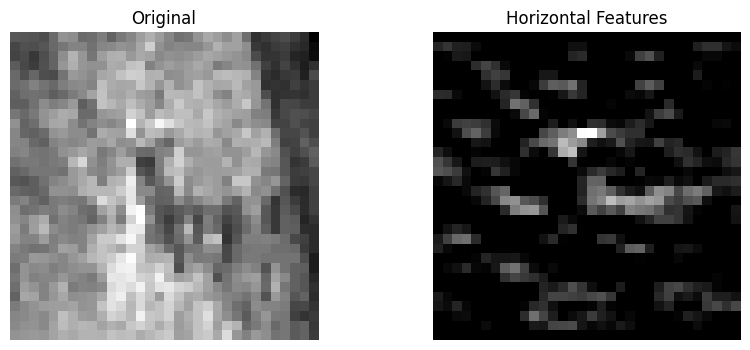

In [34]:
horizontal=cv2.filter2D(gray,-1,horizontal_kernel)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.imshow(gray,cmap="gray")

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(horizontal,cmap="gray")

plt.title("Horizontal Features")

plt.axis("off")

plt.show()